In [ ]:
!pip install openpyxl
!pip install seaborn

## PREPROCESSING

In [56]:
import pandas as pd
import numpy as np

# Load the game data from CSV
games = pd.read_csv('games.csv')
elos = pd.read_csv('elos.csv')
print("Initial Games Data:\n", games.head())

# Split the 'timecontrol' column into base time and increment
split_time = games['timecontrol'].str.split('+', expand=True)

# Convert the base time and increment to numeric values
base_time = pd.to_numeric(split_time[0])
increment = pd.to_numeric(split_time[1])

# Calculate the total time using the formula: base_time + 40 * increment
games['time'] = base_time + 40 * increment.fillna(0)

# Define a function to convert result into win/loss/draw
def convert_result(result, player_color):
    """Convert result into numeric values (1 = win, 0 = loss, 0.5 = draw) based on the player color."""
    if player_color == 'white':
        if result == '1-0':
            return 1  # Win for White
        elif result == '0-1':
            return 0  # Loss for White
        elif result == '1/2-1/2':
            return 0.5  # Draw
    elif player_color == 'black':
        if result == '1-0':
            return 0  # Loss for Black
        elif result == '0-1':
            return 1  # Win for Black
        elif result == '1/2-1/2':
            return 0.5  # Draw
    return np.nan  # If result is unrecognized

# Apply the result conversion for both White and Black players
games['white_result'] = games.apply(lambda row: convert_result(row['result'], 'white'), axis=1)
games['black_result'] = games.apply(lambda row: convert_result(row['result'], 'black'), axis=1)

# Combine both white and black results into a single dataframe to calculate performance per player
df_white = games[['white', 'time', 'white_result']].rename(columns={'white': 'player', 'white_result': 'result'})
df_black = games[['black', 'time', 'black_result']].rename(columns={'black': 'player', 'black_result': 'result'})

# Concatenate the two dataframes
df = pd.concat([df_white, df_black])

# Show a preview of the dataframe
print("Combined Dataframe (df):\n", df.head())

# Group by player and time, calculating the average result (win rate) per time control
player_performance = df.groupby(['player', 'time'])['result'].mean().reset_index()

# Show a preview of the aggregated data
print("Player Performance (Win Rate by Player and Time Control):\n", player_performance.head())

# List all games played by player 'A' with time control of 30 or 70
player_name = 'A'  # Replace with actual player's name
filtered_games = games[(games['white'] == player_name) | (games['black'] == player_name)]
filtered_games_30_70 = filtered_games[filtered_games['time'].isin([30, 70])]

# Show the filtered list of games
print(f"Games played by player {player_name} with time control 30 or 70:\n", filtered_games_30_70)


Initial Games Data:
   white black   result timecontrol
0     A    SM      1-0        60+1
1    SM     A  1/2-1/2       180+1
2    SM     A  1/2-1/2        60+1
3    SM     A      1-0        60+2
4    SM     A      1-0       120+0
Combined Dataframe (df):
   player  time  result
0      A   100     1.0
1     SM   220     0.5
2     SM   100     0.5
3     SM   140     1.0
4     SM   120     1.0
Player Performance (Win Rate by Player and Time Control):
   player  time    result
0      A    30  0.800000
1      A    60  0.454545
2      A    70  0.875000
3      A   100  0.369565
4      A   110  0.875000
Games played by player A with time control 30 or 70:
    white black   result timecontrol  time  white_result  black_result
15     A    SM      1-0        30+0    30           1.0           0.0
30    SM     A      0-1        30+1    70           0.0           1.0
32    SM     A      0-1        30+0    30           0.0           1.0
34     A    SM      1-0        30+1    70           1.0       

In [40]:
# Create a 'win_rate' for each player (white and black) based on the result
# We'll define 1 for a win, 0.5 for a draw, and 0 for a loss
def convert_result(result):
    if result == '1-0':
        return 1
    elif result == '0-1':
        return 0
    elif result == '1/2-1/2':
        return 0.5
    else:
        return np.nan

games['white_result'] = games['result'].apply(lambda x: convert_result(x) if 'A' in x else 0)
games['black_result'] = games['result'].apply(lambda x: convert_result(x) if 'SM' in x else 0)

# Combine both white and black results into a single dataframe to calculate performance per player
df_white = games[['white', 'time', 'white_result']].rename(columns={'white': 'player', 'white_result': 'result'})
df_black = games[['black', 'time', 'black_result']].rename(columns={'black': 'player', 'black_result': 'result'})
df = pd.concat([df_white, df_black])

# Aggregate by player and time, calculating the average result (win rate) per time control
player_performance = df.groupby(['player', 'time'])['result'].mean().reset_index()

# Show a preview of the aggregated data
print(player_performance.head())


  player  time  result
0      A    30     0.0
1      A    60     0.0
2      A    70     0.0
3      A   100     0.0
4      A   110     0.0


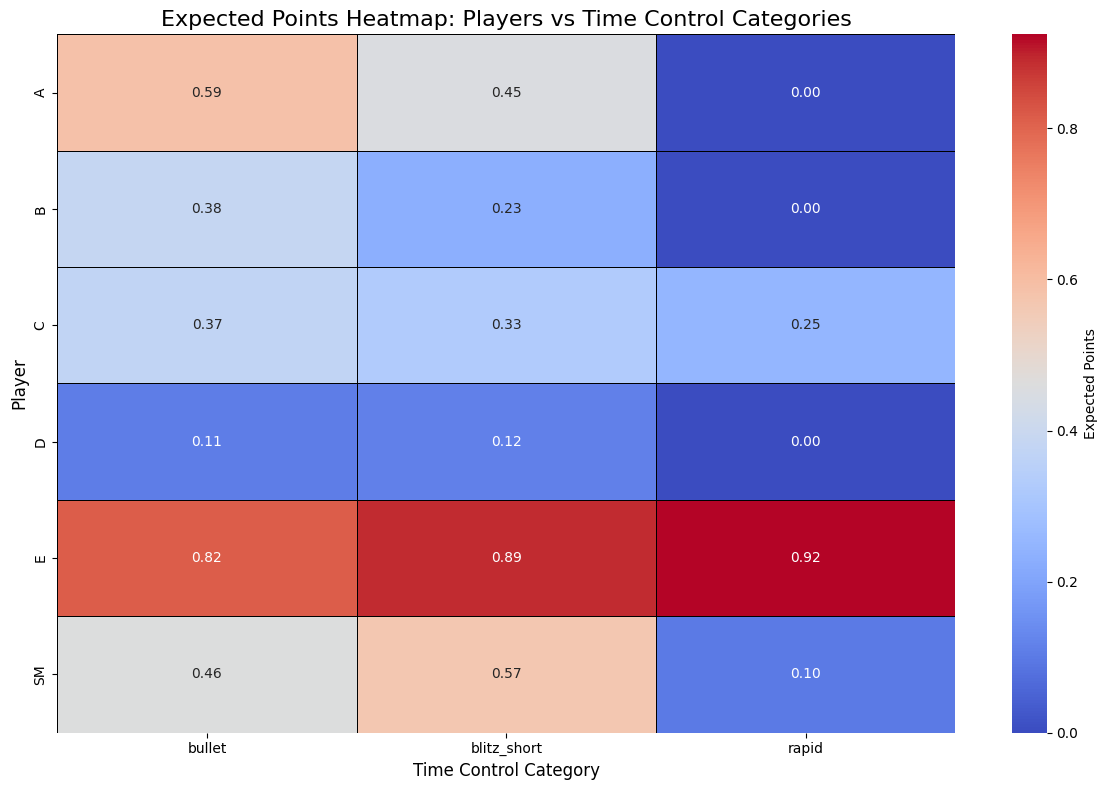

Games in each category:
 time_category
blitz_short    56
bullet         35
rapid          15
Name: count, dtype: int64


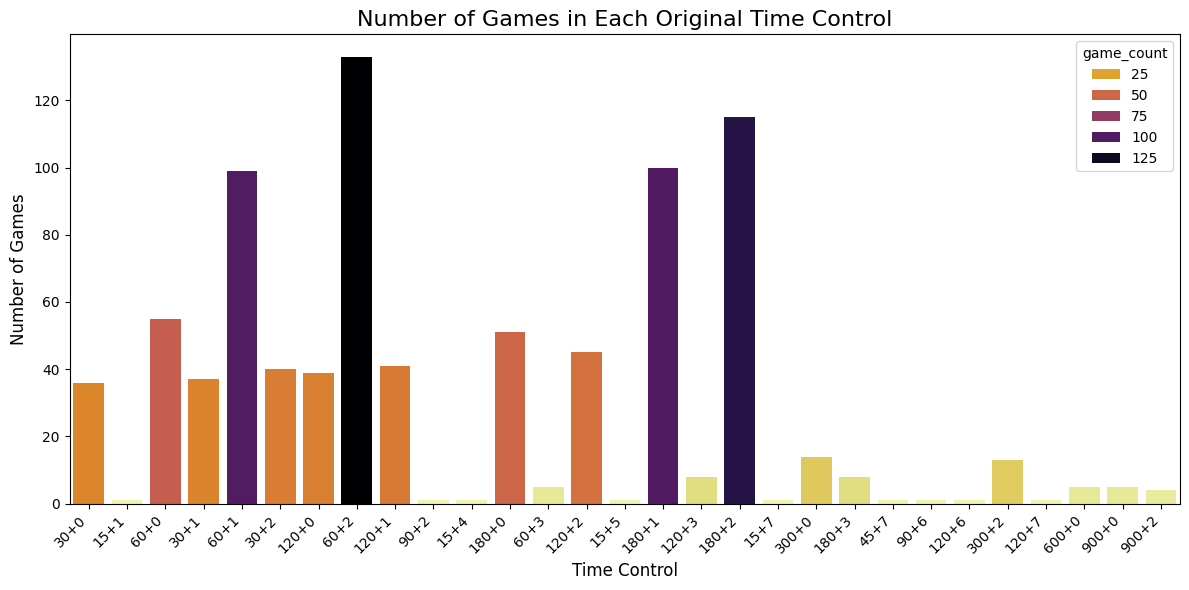

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Split 'blitz' into two halves: top half goes to 'rapid'
# Assuming player_performance['time'] exists already after preprocessing

# Step 1: Split the 'blitz' category into two subcategories
def categorize_time_control(time):
    if time <= 120:
        return 'bullet'
    elif 120 < time <= 375:  # First half of blitz time range (e.g., blitz_short)
        return 'blitz_short'
    elif 375 < time <= 750:  # Second half of blitz time range (e.g., blitz_long)
        return 'blitz'
    else:
        return 'rapid'

# Apply the categorization function to the 'time' column
player_performance['time_category'] = player_performance['time'].apply(categorize_time_control)

# Step 2: Move top half of 'blitz' into 'rapid'
blitz_times = player_performance[player_performance['time_category'] == 'blitz']
blitz_cutoff = blitz_times['time'].median()  # Split by median or any other threshold
player_performance.loc[player_performance['time'] >= blitz_cutoff, 'time_category'] = 'rapid'

# Step 3: Ensure no duplicates by grouping by player and time category, taking the mean of the results
player_performance_grouped = player_performance.groupby(['player', 'time_category'], as_index=False)['result'].mean()

# Step 4: Create a pivot table to reshape the data for the heatmap, now using the updated time categories
heatmap_data = player_performance_grouped.pivot(index='player', columns='time_category', values='result')
heatmap_data = heatmap_data[["bullet", "blitz_short", "rapid"]]

# Step 5: Set up the plot
plt.figure(figsize=(12, 8))

# Step 6: Create the heatmap using seaborn
sns.heatmap(
    heatmap_data, 
    annot=True, fmt=".2f", cmap="coolwarm", 
    cbar_kws={'label': 'Expected Points'},
    linewidths=0.5, linecolor='black'
)

# Step 7: Add title and labels
plt.title('Expected Points Heatmap: Players vs Time Control Categories', fontsize=16)
plt.xlabel('Time Control Category', fontsize=12)
plt.ylabel('Player', fontsize=12)

# Step 8: Show the plot
plt.tight_layout()
plt.show()

# Step 9: Print out how many games are in each category for reference
category_counts = player_performance['time_category'].value_counts()
print("Games in each category:\n", category_counts)



import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

split_time = games['timecontrol'].str.split('+', expand=True)
base_time = pd.to_numeric(split_time[0])
increment = pd.to_numeric(split_time[1])

# Calculate the total time using the formula: base_time + 40 * increment
games['time'] = base_time + 40 * increment.fillna(0)

# Step 1: Calculate the number of games for each time control
timecontrol_counts = games['timecontrol'].value_counts().reset_index()
timecontrol_counts.columns = ['timecontrol', 'game_count']

# Step 2: Add the computed 'time' for each time control to use for sorting
timecontrol_counts['time'] = timecontrol_counts['timecontrol'].map(
    lambda timecontrol: base_time[games['timecontrol'] == timecontrol].iloc[0] + 
                        40 * increment[games['timecontrol'] == timecontrol].iloc[0]
)

# Step 3: Sort timecontrols by the calculated time
timecontrol_counts = timecontrol_counts.sort_values(by='time')

# Step 4: Plot how many games have been played for each original time control
plt.figure(figsize=(12, 6))

# Use a barplot where the color intensity depends on the number of games (game_count)
sns.barplot(x='timecontrol', y='game_count', data=timecontrol_counts, palette="inferno_r", hue='game_count', dodge=False)

# Add title and labels
plt.title('Number of Games in Each Original Time Control', fontsize=16)
plt.xlabel('Time Control', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if necessary

# Show the plot
plt.tight_layout()
plt.show()


        name engine  mean_rating        sd  lower_95  upper_95
0  rating[6]      E     2346.602  26.76453  2295.606  2400.557
1  rating[1]      A     2048.656  29.92792  1989.310  2107.976
2  rating[2]     SM     2039.934  19.28851  2002.299  2077.634
3  rating[4]      C     1913.215  43.04495  1827.217  1995.274
4  rating[3]      B     1893.322  46.24080  1802.212  1982.908
5  rating[5]      D     1757.528  30.15949  1697.517  1814.783


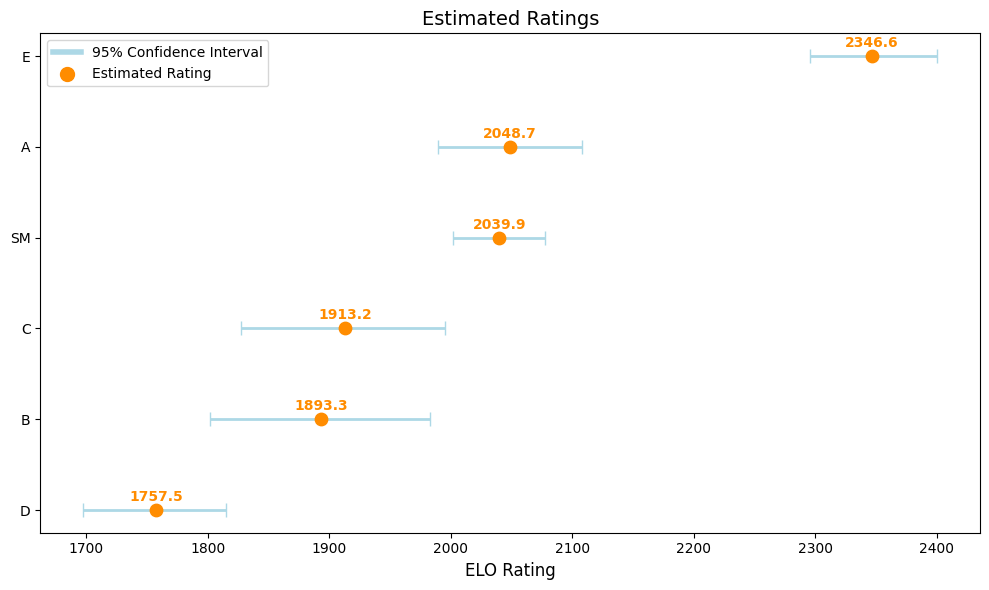

In [163]:
import matplotlib.pyplot as plt

# Assuming 'elos' is the DataFrame already available
print(elos)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the confidence intervals and mean ratings for each player
for idx, row in elos.iterrows():
    # Plot the mean rating (orange dot)
    plt.scatter(row['mean_rating'], idx, color='darkorange', s=80, zorder=5)
    
    # Horizontal error bars (double lines for the error bars)
    plt.errorbar(
        row['mean_rating'], idx, 
        xerr=[[row['mean_rating'] - row['lower_95']], [row['upper_95'] - row['mean_rating']]],  # Error bars for the left and right side
        fmt='o', color='lightblue', markersize=8, elinewidth=2, capsize=5, zorder=2
    )

    # Add the mean rating value below the orange dot
    plt.text(row['mean_rating'], idx - 0.22, f'{(row["mean_rating"]):.1f}', 
             color='darkorange', ha='center', va='top', fontsize=10, fontweight='bold')

    # Color fading effect for the error bars (using alpha for waning color)

# Customize the plot
plt.yticks(range(len(elos)), elos['engine'])  # Set the player names on the y-axis
plt.xlabel('ELO Rating', fontsize=12)
plt.title('Estimated Ratings', fontsize=14)


# Reverse the y-axis so highest ratings are at the top
plt.gca().invert_yaxis()
# 
# Add confidence interval legend
plt.plot([], [], color='lightblue', lw=4, label='95% Confidence Interval')
plt.scatter([], [], color='darkorange', s=100, label='Estimated Rating')

# Show legend
plt.legend(loc='upper left', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()


        name engine  mean_rating        sd  lower_95  upper_95
0  rating[6]      E     2346.602  26.76453  2295.606  2400.557
1  rating[1]      A     2048.656  29.92792  1989.310  2107.976
2  rating[2]     SM     2039.934  19.28851  2002.299  2077.634
3  rating[4]      C     1913.215  43.04495  1827.217  1995.274
4  rating[3]      B     1893.322  46.24080  1802.212  1982.908
5  rating[5]      D     1757.528  30.15949  1697.517  1814.783


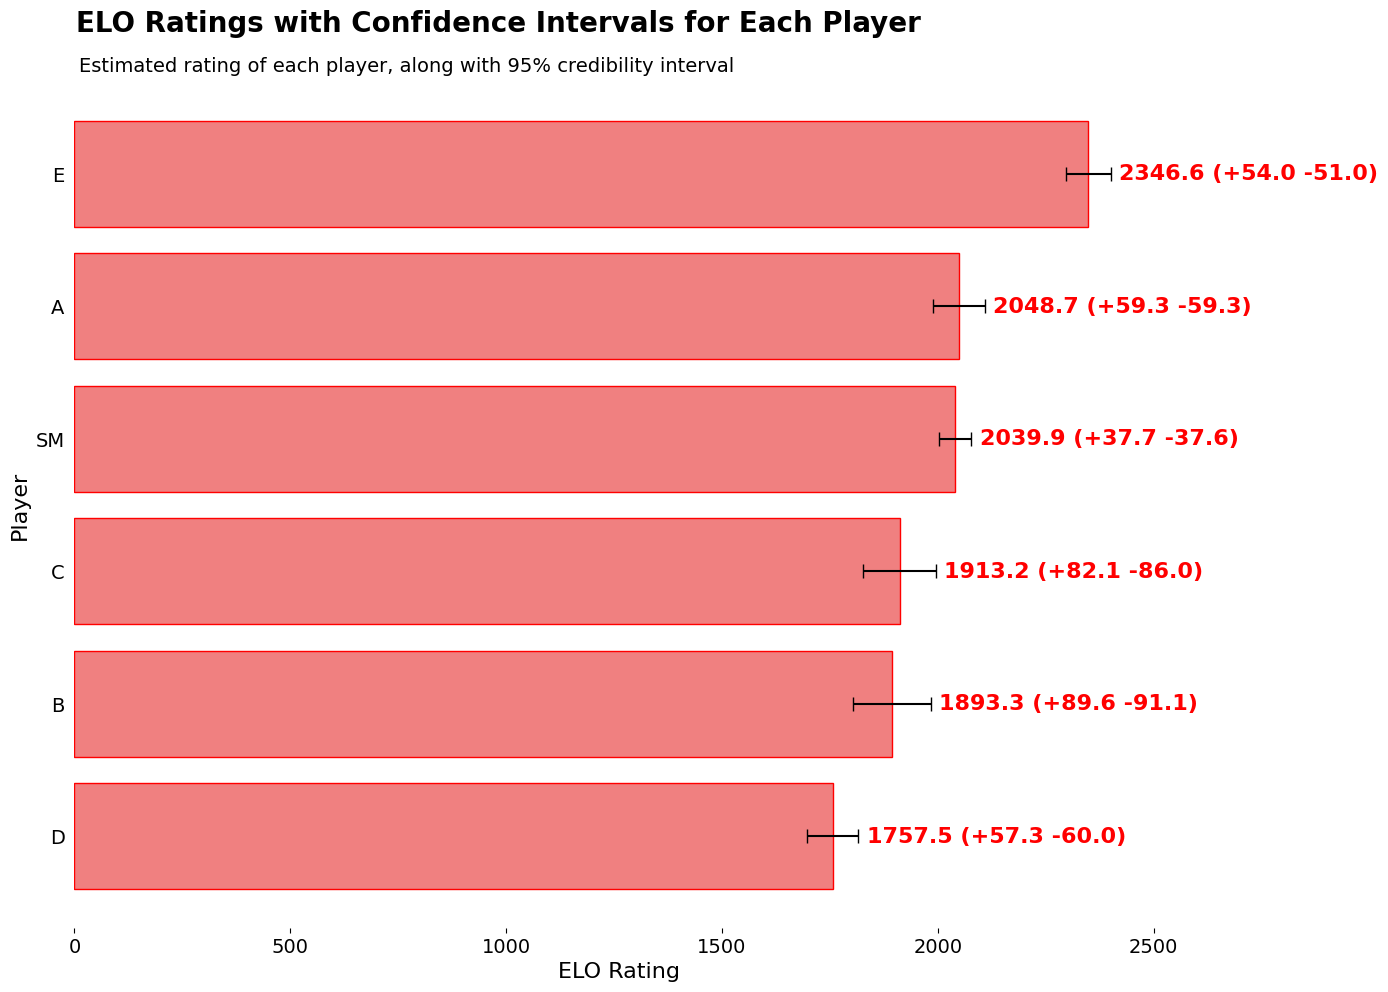

In [164]:
import matplotlib.pyplot as plt

# Assuming 'elos' is the DataFrame already available
print(elos)

# Sort players by mean ELO rating in descending order (strongest to weakest)
elos_sorted = elos.sort_values('mean_rating', ascending=False)

# Create the plot with a larger figure size for more space
plt.figure(figsize=(14, 10))  # Increase figure size for more space

# Plot the bars with error bars for each player, using the sorted order for the y-axis
bars = plt.barh(elos_sorted['engine'], elos_sorted['mean_rating'], color='lightcoral', 
                edgecolor='red', 
                xerr=[elos_sorted['mean_rating'] - elos_sorted['lower_95'], 
                      elos_sorted['upper_95'] - elos_sorted['mean_rating']], 
                capsize=5, ecolor='black')

# Add the mean rating value above each bar, placing the text slightly above the bar's end
for idx, row in elos_sorted.iterrows():
    # The position to place the text is slightly above the rightmost end of the error bar
    rightmost_point = row['upper_95']
    # Calculate the difference between the mean rating and the 95% confidence interval
    lower_diff = row['mean_rating'] - row['lower_95']
    upper_diff = row['upper_95'] - row['mean_rating']
    # Add the text with the (+/- difference)
    plt.text(rightmost_point + 20, idx, 
             f'{row["mean_rating"]:.1f} (+{upper_diff:.1f} -{lower_diff:.1f})', 
             color='red', ha='left', va='center', fontsize=16, fontweight='bold')

# Customize the plot
plt.ylabel('Player', fontsize=16)
plt.xlabel('ELO Rating', fontsize=16)
plt.title('ELO Ratings with Confidence Intervals for Each Player', x = 0.39, y = 1.05, fontsize=20, fontweight='bold')  
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(left=False)  
# Add a subtitle below the title with bold text, aligned to the left
plt.figtext(0.06, 0.94, 'Estimated rating of each player, along with 95% credibility interval', 
            ha='left', va='top', fontsize=14)

# Remove the border (spines) of the plot
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Reverse the y-axis so the highest ratings are at the top
plt.gca().invert_yaxis()

# Increase the margins to prevent clipping of labels
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)  # Increased figure size and adjusted margins

# Explicitly show the x-axis (it should be visible by default)
plt.gca().get_xaxis().set_visible(True)

# Show the plot
plt.tight_layout()
plt.show()


        name engine  mean_rating        sd  lower_95  upper_95
0  rating[6]      E     2346.602  26.76453  2295.606  2400.557
1  rating[1]      A     2048.656  29.92792  1989.310  2107.976
2  rating[2]     SM     2039.934  19.28851  2002.299  2077.634
3  rating[4]      C     1913.215  43.04495  1827.217  1995.274
4  rating[3]      B     1893.322  46.24080  1802.212  1982.908
5  rating[5]      D     1757.528  30.15949  1697.517  1814.783


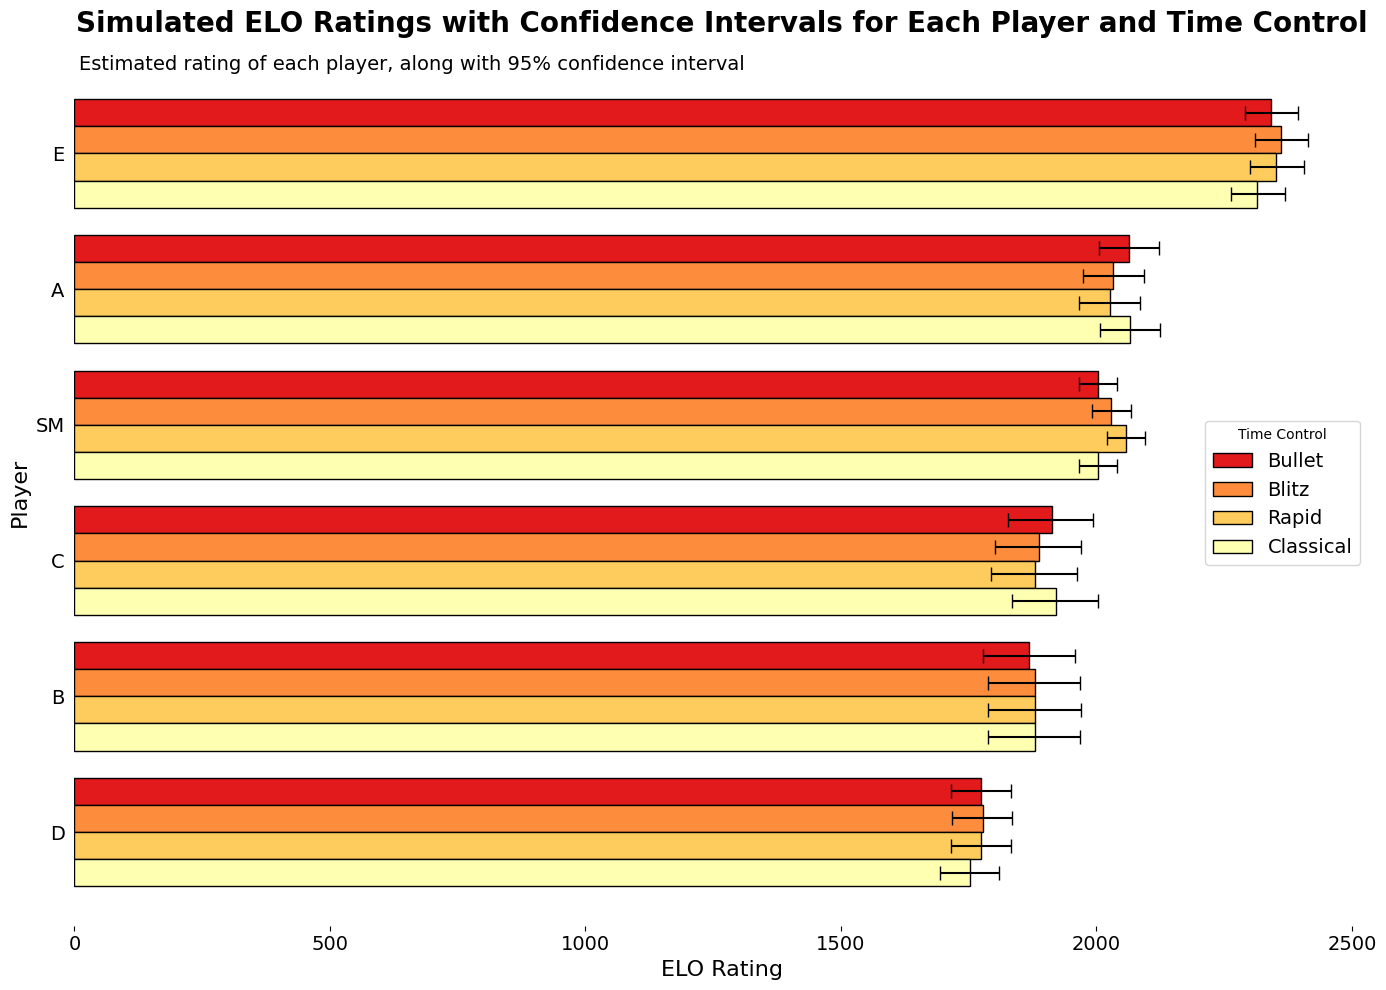

In [180]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming 'elos' is the DataFrame already available
print(elos)

# Simulating Elo ratings for 4 time controls based on the actual Elo
# Placeholder for when the real data is available
time_controls = ['Bullet', 'Blitz', 'Rapid', 'Classical']

# Simulate Elo ratings for each player and time control by adding some noise
elos_simulated = []
for idx, row in elos.iterrows():
    for time_control in time_controls:
        # Simulate slight variations in Elo for different time controls
        variation = np.random.normal(0, 20)  # Small random variation for each time control
        simulated_elo = row['mean_rating'] + variation
        
        # Append the simulated Elo rating for the time control
        elos_simulated.append({
            'engine': row['engine'],
            'time_control': time_control,
            'elo': simulated_elo,
            'lower_95': row['lower_95'] + variation,  # Simulate confidence intervals similarly
            'upper_95': row['upper_95'] + variation
        })

# Convert simulated data into a DataFrame
elos_simulated_df = pd.DataFrame(elos_simulated)

# Define the custom color palette
colors = ['#e31a1c', '#fd8d3c', '#fecc5c', '#ffffb2']

# Create the plot with a larger figure size for more space
plt.figure(figsize=(14, 10))  # Increase figure size for more space

# Set the bar width and the positions of the bars for each player and time control
bar_width = 0.2  # Make the bars thicker
indices = np.arange(len(elos))  # Player indices for the x-axis

# Plot the bars for each time control
for i, time_control in enumerate(time_controls):
    # Extract the Elo data for the current time control
    time_control_data = elos_simulated_df[elos_simulated_df['time_control'] == time_control]
    
    # Plot the bars for the current time control (adjusted for grouped barplot)
    plt.barh(indices + i * bar_width, time_control_data['elo'], 
             color=colors[i], edgecolor='black', height=bar_width, 
             label=time_control, 
             xerr=[time_control_data['elo'] - time_control_data['lower_95'], 
                   time_control_data['upper_95'] - time_control_data['elo']], 
             capsize=5, ecolor='black')

# Customize the plot
plt.ylabel('Player', fontsize=16)
plt.xlabel('ELO Rating', fontsize=16)
plt.title('Simulated ELO Ratings with Confidence Intervals for Each Player and Time Control', fontsize=20, fontweight='bold', pad=20)

# Add a subtitle below the title with bold text, aligned to the left
plt.figtext(0.06, 0.94, 'Estimated rating of each player, along with 95% confidence interval', 
            ha='left', va='top', fontsize=14)

# Remove the border (spines) of the plot
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Reverse the y-axis so the highest ratings are at the top
plt.gca().invert_yaxis()

# Increase the margins to prevent clipping of labels
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)

# Show the legend
plt.legend(title='Time Control', fontsize=14, loc = 'right')

# Adjust the y-ticks to place them between the 2nd and 3rd bars for each player group
tick_positions = indices + bar_width * 1.5  # Center the tick labels in the middle of the group
plt.xticks(fontsize = 14)
plt.yticks(tick_positions, elos['engine'], fontsize = 14)  # Set the player names to the new positions
plt.tick_params(left=False)  

# Show the plot
plt.tight_layout()
plt.show()
